### Problem Statement

### Build a model which predicts a sales based on money spend on advertisement.

### Import Necessary libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error

In [2]:
df=pd.read_csv(r"C:\Users\dssas\OneDrive\Desktop\DS\Dataset\Revenue.csv")
df.head()

,Advertising Spend (in $1000),Sales Revenue (in $1000)
0,43.71,223.67
1,95.56,505.96
2,75.88,393.65
3,63.88,310.74
4,24.04,106.73


### Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Advertising Spend (in $1000)  500 non-null    float64
 1   Sales Revenue (in $1000)      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


### Total number of rows and columns

In [4]:
df.shape

(500, 2)

In [5]:
df.dtypes

Advertising Spend (in $1000)    float64
Sales Revenue (in $1000)        float64
dtype: object

### Descriptive statistics for the columns

In [6]:
df.describe()

,Advertising Spend (in $1000),Sales Revenue (in $1000)
count,500.00000,500.000000
mean,54.87076,274.467080
std,26.88202,136.276157
min,10.46000,31.570000
25%,31.71750,157.965000
50%,56.18500,281.025000
75%,78.05250,393.380000
max,99.37000,521.500000


### Check null values

df.isna().sum()

### Check Duplicate values

In [8]:
df.duplicated().sum()

np.int64(0)

### Use boxplot to check outliers are present or not

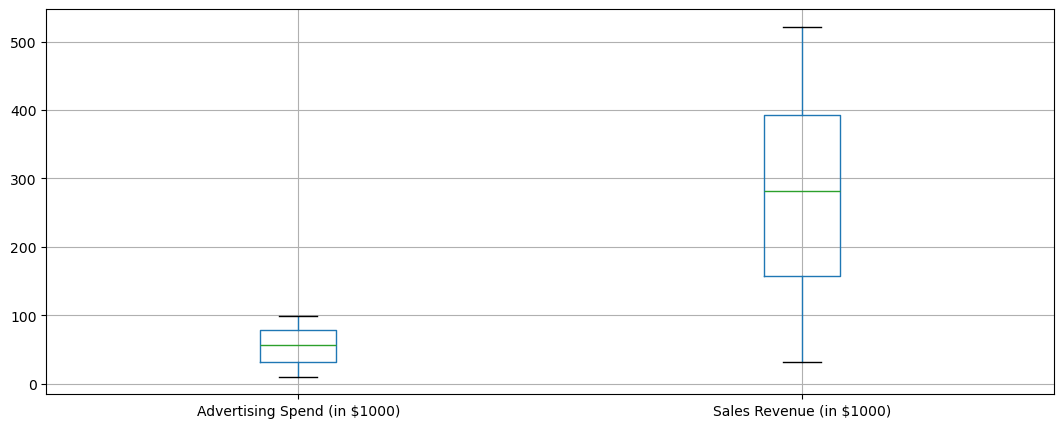

In [9]:
plt.figure(figsize=(13,5))
df.boxplot()
plt.show()

### Define X and Y

In [10]:
x=df[['Advertising Spend (in $1000)']]
y=df['Sales Revenue (in $1000)']

### Model Creation

#### Creates an object of the LinearRegression model.

In [12]:
lr=LinearRegression()
lr.fit(x,y)


LinearRegression()

#### coef_ gives the coefficient (slope) learned by the Linear Regression model after training.
#### It tells: “How much does y change when x increases by 1 unit?”

In [13]:
lr.coef_

array([5.03831975])

#### intercept_ gives the intercept (constant value) of the Linear Regression model.
#### It is the value of y when x = 0.

In [14]:
lr.intercept_

np.float64(-1.9893539166221785)

### Predictions using the trained Linear Regression model.

In [15]:
pred=lr.predict(x)
pred

array([218.23560244, 479.47248159, 380.31834887, 319.85851184,
       119.13185292, 119.13185292,  74.74425591, 441.18125147,
       320.96694219, 369.4859614 ,  57.71473514, 488.18877476,
       425.86475943, 144.67613406, 130.82075475, 131.57650271,
       186.34303841, 286.35368549, 244.28371556, 180.4482043 ,
       325.85411235, 111.62475649, 180.85126988, 214.50724583,
       255.21686942, 404.45190048, 138.93244955, 281.56728173,
       317.03705278,  69.45402017, 323.88916764, 125.7320518 ,
        77.86801415, 478.66635043, 486.27421325, 414.98198876,
       186.5445712 ,  92.68067422, 358.65357393, 247.96168898,
       103.71459448, 272.95175495,  63.96225164, 460.72993211,
       165.73631063, 348.82885042, 189.71871265, 284.2375912 ,
       296.2791754 , 132.23148428, 488.03762517, 399.8670295 ,
       474.38377864, 454.12973323, 319.50582946, 466.42323343,
        88.49886883, 137.26980403,  68.89980499, 195.91584594,
       224.63426853, 171.42961195, 424.20211391, 210.17

### Evaluate the model

In [20]:
mse=mean_squared_error(y,pred)
mae=mean_absolute_error(y,pred)
r2_score(y,pred)

0.9877692520568953

In [24]:
print(f'mse= {mse}')
print(f'mae={mae}')
print(f'r2_score= {r2_score(y,pred)}')

mse= 226.6852760564629
mae=12.090057664255367
r2_score= 0.9877692520568953


### Result after model creation

In [26]:
df['Pred Sales Revenue (in $1000)']= pred
df.head()

,Advertising Spend (in $1000),Sales Revenue (in $1000),Pred Sales Revenue (in $1000)
0,43.71,223.67,218.235602
1,95.56,505.96,479.472482
2,75.88,393.65,380.318349
3,63.88,310.74,319.858512
4,24.04,106.73,119.131853


### Scatterplot to understand the relationship between actual value and predicted value

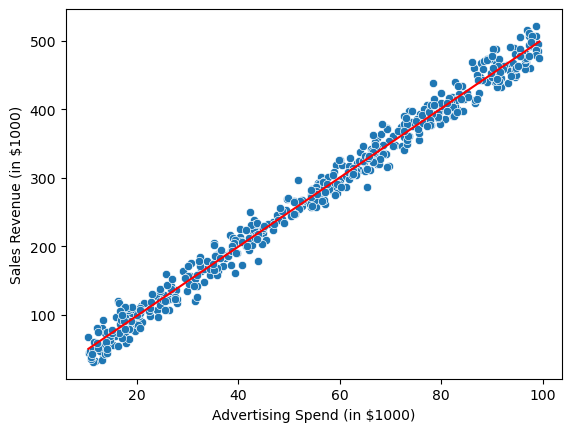

In [31]:
sns.scatterplot(x=df['Advertising Spend (in $1000)'], y=df['Sales Revenue (in $1000)']) # Actual Value
sns.lineplot(x=df['Advertising Spend (in $1000)'], y= pred, color= 'red') # Predicted Value (Best fit line) 
plt.show()

### Final Conclusion

#### The model achieved an R² score of 98.78%, indicating an excellent linear relationship between the two variables. The low MAE (12.09) and MSE (226.69) further demonstrate that the model predicts sales revenue accurately. Overall, the analysis shows that Advertising Spend is a strong predictor of Sales Revenue, making the model suitable for forecasting revenue and supporting business decisions related to advertising budget allocation.